# Etape 2 - Preprocessing et extraction de features

**Projet BrainScanAI** - Detection de tumeurs cerebrales  
Objectif : preparer les images (redimensionnement, normalisation) et extraire des vecteurs de features a l'aide d'un modele pre-entraine (ResNet50).

## 1. Imports

In [1]:
import sys
from pathlib import Path

# Ajouter la racine du projet au chemin Python pour pouvoir importer src/
sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from sklearn.model_selection import train_test_split

print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible  : {torch.cuda.is_available()}")

PyTorch version : 2.2.2+cu121
GPU disponible  : True


## 2. Configuration et chemins

In [2]:
# Importation des chemins, constantes et appareil de calcul definis dans src/config.py
from src.config import (
    PROCESSED_DIR, FEATURES_DIR, IMAGENET_MEAN, IMAGENET_STD, IMG_SIZE,
    DEVICE, METADATA_PATH, RANDOM_STATE
)

print(f"Appareil utilise : {DEVICE}")
print(f"Taille cible des images : {IMG_SIZE}x{IMG_SIZE}")
print(f"Features sauvegardees dans : {FEATURES_DIR}")

Appareil utilise : cuda
Taille cible des images : 224x224
Features sauvegardees dans : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed\features


## 3. Chargement du DataFrame produit a l'etape 1

In [3]:
# Charger le DataFrame sauvegarde a l'etape eploration_donnees
# Ce CSV contient les colonnes : path, label, split
df = pd.read_csv(METADATA_PATH)
print(f"Total images : {len(df)}")
print(df["label"].value_counts(dropna=False))

Total images : 1506
label
NaN       1406
cancer      50
normal      50
Name: count, dtype: int64


## 3.1 Séparation train/test (avant toute transformation)

En production, le split est effectué **immédiatement après le chargement des données brutes**, avant tout preprocessing ou augmentation.  
Cela garantit que les images de test ne sont **jamais vues** sous aucune forme pendant l'entraînement.

- 80 images labelisées → entraînement (augmentation autorisée)  
- 20 images labelisées → test set **figé** (jamais augmenté, jamais utilisé avant l'évaluation finale)

In [4]:
df_labeled = df[df["label"].notna()].reset_index(drop=True)

# Split stratifié : garantit 10 cancer + 10 normal dans le test set
df_train_labeled, df_test_labeled = train_test_split(
    df_labeled,
    test_size=0.2,
    stratify=df_labeled["label"],
    random_state=RANDOM_STATE
)
df_train_labeled = df_train_labeled.reset_index(drop=True)
df_test_labeled  = df_test_labeled.reset_index(drop=True)

# Sauvegarde immédiate du test set -- réutilisé par les étapes 3 et 4
df_test_labeled.to_csv(PROCESSED_DIR / "test_set.csv", index=False)

print(f"Images labelisées total   : {len(df_labeled)}")
print(f"  Train labelisé          : {len(df_train_labeled)}  (augmentation + entraînement)")
print(f"  Test (mis de côté)      : {len(df_test_labeled)}   (évaluation finale uniquement)")
print(f"\nTest set sauvegardé : data/processed/test_set.csv")
print(df_test_labeled["label"].value_counts())

Images labelisées total   : 100
  Train labelisé          : 80  (augmentation + entraînement)
  Test (mis de côté)      : 20   (évaluation finale uniquement)

Test set sauvegardé : data/processed/test_set.csv
label
normal    10
cancer    10
Name: count, dtype: int64


## 4. Pipeline de preprocessing

Avant de passer une image dans ResNet50, on doit la preparer en 3 etapes :
1. **Redimensionner** a 224x224 (taille attendue par ResNet)
2. **Convertir** en tenseur PyTorch (tableau numerique entre 0 et 1)
3. **Normaliser** avec les statistiques ImageNet (ce que ResNet attend car il a ete entraine avec ces valeurs)

In [5]:
# transforms.Compose enchaine plusieurs transformations dans l'ordre
preprocess = transforms.Compose([
    # Redimensionner l'image a 224x224 pixels
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # Convertit l'image PIL en tenseur PyTorch et ramene les valeurs dans [0, 1]
    transforms.ToTensor(),

    # Normaliser chaque canal avec la moyenne et l'ecart-type d'ImageNet
    # Formule : (pixel - mean) / std - centre et reduit les valeurs
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Pipeline de preprocessing pret.")
print(f"  Redimensionnement : {IMG_SIZE}x{IMG_SIZE}")
print(f"  Normalisation mean : {IMAGENET_MEAN}")
print(f"  Normalisation std  : {IMAGENET_STD}")

Pipeline de preprocessing pret.
  Redimensionnement : 224x224
  Normalisation mean : [0.485, 0.456, 0.406]
  Normalisation std  : [0.229, 0.224, 0.225]


## 5. Classe Dataset PyTorch

PyTorch utilise une classe `Dataset` pour charger les donnees.  
Elle doit implementer 2 methodes obligatoires :
- `__len__` : retourne le nombre total d'images
- `__getitem__` : retourne une image (et son label) a partir de son index

Le `DataLoader` utilise ce Dataset pour charger les images par **lots (batches)**, ce qui est plus efficace que de les charger une par une.

In [6]:
class BrainScanDataset(Dataset):
    """Dataset PyTorch pour les images cerebrales."""

    def __init__(self, dataframe, transform=None):
        # Stocke le DataFrame et le pipeline de preprocessing
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        # Retourne le nombre total d'images dans le dataset
        return len(self.df)

    def __getitem__(self, idx):
        # Recupere le chemin de l'image a l'index idx
        path = self.df.loc[idx, "path"]

        # Ouvre l'image et la convertit en RGB
        # convert("RGB") garantit 3 canaux, requis par ResNet
        img = Image.open(path).convert("RGB")

        # Applique le pipeline de preprocessing si defini
        if self.transform:
            img = self.transform(img)

        return img, path


# Instanciation du dataset avec toutes les images et le preprocessing
dataset = BrainScanDataset(df, transform=preprocess)

# Le DataLoader charge les images par lots de 32 pour accelerer l'extraction
# num_workers=0 evite les problemes de parallelisme sur Windows
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Dataset : {len(dataset)} images")
print(f"Nombre de batches : {len(loader)} (batch_size=32)")

Dataset : 1506 images
Nombre de batches : 48 (batch_size=32)


## 6. Verification du preprocessing sur une image

Forme du tenseur : torch.Size([3, 224, 224])
Valeur min : -2.1179
Valeur max : 2.2740
Chemin image : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\avec_labels\cancer\05340cd4-3bb2-459d-9937-bf27d52d8351.jpg


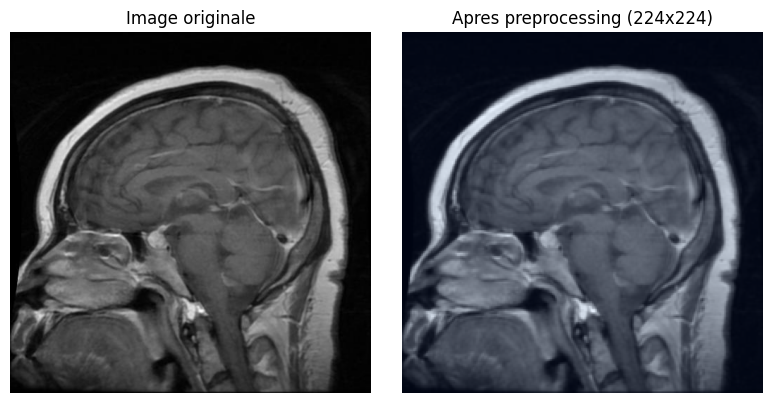

In [7]:
# tester le preprocessing sur la premiere image du dataset
img_tensor, img_path = dataset[0]

# img_tensor est un tenseur PyTorch de forme (canaux, hauteur, largeur)
print(f"Forme du tenseur : {img_tensor.shape}")   
print(f"Valeur min : {img_tensor.min():.4f}")
print(f"Valeur max : {img_tensor.max():.4f}")
print(f"Chemin image : {img_path}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Image originale
axes[0].imshow(Image.open(img_path).convert("RGB"))
axes[0].set_title("Image originale")
axes[0].axis("off")

# Image apres preprocessing - on denormalise pour l'affichage
# permute(1, 2, 0) passe de (C, H, W) a (H, W, C) pour matplotlib
img_display = img_tensor.permute(1, 2, 0).numpy()
# normalisation min max
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
axes[1].imshow(img_display)
axes[1].set_title(f"Apres preprocessing ({IMG_SIZE}x{IMG_SIZE})")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Chargement de ResNet50 et suppression de la tete de classification

ResNet50 est compose de deux parties :
- **Le corps (backbone)** : couches convolutionnelles qui extraient les features - à garder
- **La tete (classifier)** : une couche finale qui classe en 1000 categories ImageNet - à supprimer

En retirant la tete, le modele produit un vecteur de **2048 valeurs** par image au lieu d'une prediction de classe (1000 classes).

Couche average pooling, avant la fc (fully connected), choisie car elle fournit une représentation globale de l'image en 2048 features, directement exploitable pour le clustering et la classification.  

In [8]:
# Charger ResNet50 avec les poids pre-entraines sur ImageNet
# weights=DEFAULT charge automatiquement les meilleurs poids disponibles
backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Geler tous les parametres : pas de modification de poids du modele
# utilisation uniquement pour l'extraction des features, pas pour l'entrainement
for param in backbone.parameters():
    param.requires_grad = False

# Retirer la derniere couche (fc = fully connected = classificateur 1000 classes)
# nn.Identity() la remplace par une couche qui ne fait rien (passe-plat)
import torch.nn as nn
backbone.fc = nn.Identity()

# Envoie le modele sur le bon appareil (GPU ou CPU)
backbone = backbone.to(DEVICE)

# Mode evaluation : desactive le dropout et la batch normalization en mode entrainement
# Toujours utiliser .eval() quand on n'entraine pas le modele
backbone.eval()

print("ResNet50 charge et pret pour l'extraction de features.")
print(f"Taille du vecteur de features par image : 2048")

ResNet50 charge et pret pour l'extraction de features.
Taille du vecteur de features par image : 2048


## 8. Extraction des features

Toutes les images sont passées dans ResNet50 par lots de 32.  
Pour chaque image, un vecteur de **2048 valeurs** est obtenu et qui resume son contenu visuel.  
A la fin, une matrice de forme **(1506 images x 2048 features)** est obtenue.

In [ ]:
import time

all_features = []  # Contiendra les vecteurs de features de chaque batch
all_paths    = []  # Conserve l'ordre des chemins pour retrouver l'image correspondante

t0 = time.time()

# torch.no_grad() desactive le calcul des gradients
# Inutile ici car on n'entraine pas le modele 
with torch.no_grad():
    for batch_idx, (images, paths) in enumerate(loader):
        # Envoie le batch d'images sur le bon appareil
        images = images.to(DEVICE)

        # Passe les images dans ResNet50 - vecteurs de features de taille batch_size x 2048
        features = backbone(images)

        # Ramene les features sur le CPU et les convertit en tableau numpy
        all_features.append(features.cpu().numpy())
        all_paths.extend(paths)

        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch {batch_idx + 1}/{len(loader)} traite")

# Concatener tous les batches en une seule matrice numpy
features_matrix = np.concatenate(all_features, axis=0)

print(f"\nExtraction terminee.")
print(f"Forme de la matrice de features : {features_matrix.shape}")
print(f"  {features_matrix.shape[0]} images x {features_matrix.shape[1]} features par image")
print(f"Temps d'extraction : {time.time() - t0:.1f} secondes")  

  Batch 10/48 traite
  Batch 20/48 traite
  Batch 30/48 traite
  Batch 40/48 traite

Extraction terminee.
Forme de la matrice de features : (1506, 2048)
  1506 images x 2048 features par image
Temps d'extraction : 12.1 secondes


### Stratégie adoptée pour limiter la consommation mémoire :
- Traitement par batches de 32 → jamais plus de 32 images chargées simultanément
- torch.no_grad()              → pas de stockage des gradients (~2× moins de mémoire)
- num_workers=0                → pas de processus parallèles supplémentaires

In [11]:
# Empreinte mémoire de la matrice de features
ram_mo = features_matrix.nbytes / 1024**2
print(f"Empreinte mémoire de la matrice de features : {ram_mo:.1f} Mo")
print(f"  Calcul : {features_matrix.shape[0]} images × {features_matrix.shape[1]} features × 4 octets (float32)")

Empreinte mémoire de la matrice de features : 11.8 Mo
  Calcul : 1506 images × 2048 features × 4 octets (float32)


## 9. Sauvegarde des features

In [12]:
# Sauvegarder la matrice de features au format numpy binaire (.npy)
features_path = FEATURES_DIR / "resnet50_features.npy"
np.save(features_path, features_matrix)
print(f"Features sauvegardees : {features_path}")

# Sauvegarder les metadonnees associees a chaque image (chemin, label, split)
meta_df = df.set_index("path").loc[all_paths].reset_index()
meta_path = FEATURES_DIR / "resnet50_metadata.csv"
meta_df.to_csv(meta_path, index=False)
print(f"Metadonnees sauvegardees : {meta_path}")

print(f"\nRecapitulatif :")
print(f"  resnet50_features.npy  -> matrice {features_matrix.shape}")
print(f"  resnet50_metadata.csv  -> {len(meta_df)} lignes (path, label, split)")

Features sauvegardees : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed\features\resnet50_features.npy
Metadonnees sauvegardees : C:\Users\fkhellad\Formation_IA\Projet7_mission\data\processed\features\resnet50_metadata.csv

Recapitulatif :
  resnet50_features.npy  -> matrice (1506, 2048)
  resnet50_metadata.csv  -> 1506 lignes (path, label, split)


## 10. Verification : rechargement et visualisation rapide

In [13]:
# Recharger les features pour verifier que la sauvegarde s'est bien passee
features_check = np.load(FEATURES_DIR / "resnet50_features.npy")
meta_check     = pd.read_csv(FEATURES_DIR / "resnet50_metadata.csv")

print(f"Features rechargees : {features_check.shape}")
print(f"Metadonnees rechargees : {meta_check.shape}")
print(meta_check["label"].value_counts(dropna=False))

Features rechargees : (1506, 2048)
Metadonnees rechargees : (1506, 3)
label
NaN       1406
cancer      50
normal      50
Name: count, dtype: int64


## 11. Augmentation des données labelisées

Les **80 images d'entraînement** (test set déjà exclu) sont augmentées avec 9 transformations chacune.  
→ **720 images supplémentaires** avec leurs vrais labels conservés.

Ces images augmentées serviront à l'étape 4 pour le modèle semi-supervisé enrichi (modèle C).  
Les 20 images de test sont **définitivement exclues** depuis la section 3.1 — elles ne seront jamais augmentées.

In [14]:
class AddGaussianNoise:
    """Ajout de bruit gaussien sur le tenseur normalisé."""
    def __init__(self, std=0.05):
        self.std = std
    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std


AUG_TRANSFORMS = {

    # Symétrie horizontale -- valide pour les IRM cérébrales (symétrie bilatérale du cerveau)
    "hflip": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Rotation +10° -- simule une légère inclinaison de la tête lors de l'acquisition scanner
    "rot_p10": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(10, 10)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Rotation -10° -- même principe, sens antihoraire
    "rot_n10": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(-10, -10)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Rotation +20° -- inclinaison plus prononcée, reste réaliste pour un patient non parfaitement aligné
    "rot_p20": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(20, 20)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Rotation -20° -- sens antihoraire
    "rot_n20": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(-20, -20)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Zoom avant (recadrage central 90% puis resize) -- simule des variations de distance scanner/patient
    "zoom_in": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.CenterCrop(int(IMG_SIZE * 0.9)),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Luminosité +20% -- simule une intensité de contraste plus élevée à l'acquisition IRM
    "bright_up": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=(1.2, 1.2)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Luminosité -20% -- simule une intensité de contraste plus faible à l'acquisition IRM
    "bright_down": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=(0.8, 0.8)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]),

    # Bruit gaussien (std=0.05) -- simule le bruit électronique inhérent aux scanners IRM
    "noise": transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        AddGaussianNoise(std=0.05),
    ]),
}

print(f"Images à augmenter (train labelisé) : {len(df_train_labeled)}")
print(f"Transformations par image           : {len(AUG_TRANSFORMS)}")
print(f"Total images augmentées             : {len(df_train_labeled) * len(AUG_TRANSFORMS)}")
print(f"\nTransformations : {list(AUG_TRANSFORMS.keys())}")

Images à augmenter (train labelisé) : 80
Transformations par image           : 9
Total images augmentées             : 720

Transformations : ['hflip', 'rot_p10', 'rot_n10', 'rot_p20', 'rot_n20', 'zoom_in', 'bright_up', 'bright_down', 'noise']


In [15]:
aug_features_list = []
aug_meta_rows     = []

backbone.eval()
with torch.no_grad():
    for i, row in df_train_labeled.iterrows():
        img = Image.open(row["path"]).convert("RGB")

        for aug_name, aug_transform in AUG_TRANSFORMS.items():
            img_tensor = aug_transform(img).unsqueeze(0).to(DEVICE)
            feat = backbone(img_tensor).cpu().numpy()[0]
            aug_features_list.append(feat)
            aug_meta_rows.append({
                "original_path": row["path"],
                "label":         row["label"],
                "split":         row["split"],
                "aug_type":      aug_name,
            })

        if (i + 1) % 20 == 0:
            print(f"  {i + 1}/{len(df_train_labeled)} images traitees")

features_aug = np.array(aug_features_list)   # (720, 2048)
meta_aug_df  = pd.DataFrame(aug_meta_rows)

print(f"\nExtraction terminee.")
print(f"Forme de la matrice augmentee : {features_aug.shape}")
print(f"Distribution des labels : {dict(meta_aug_df['label'].value_counts())}")

  20/80 images traitees
  40/80 images traitees
  60/80 images traitees
  80/80 images traitees

Extraction terminee.
Forme de la matrice augmentee : (720, 2048)
Distribution des labels : {'cancer': 360, 'normal': 360}


In [ ]:
# Sauvegarde dans features/ -- même dossier que resnet50_features_augmented.npy
np.save(FEATURES_DIR / "resnet50_features_augmented.npy", features_aug)
meta_aug_df.to_csv(FEATURES_DIR / "resnet50_metadata_augmented.csv", index=False)

print(f"Fichiers sauvegardes dans data/processed/features/ :")
print(f"  resnet50_features_augmented.npy  -> matrice {features_aug.shape}")
print(f"  resnet50_metadata_augmented.csv  -> {len(meta_aug_df)} lignes (original_path, label, split, aug_type)")
print(meta_aug_df.head(3)) 

Fichiers sauvegardes dans data/processed/features/ :
  resnet50_features_augmented.npy  -> matrice (720, 2048)
  resnet50_metadata_augmented.csv  -> 720 lignes (original_path, label, split, aug_type)
                                       original_path   label    split aug_type
0  C:\Users\fkhellad\Formation_IA\Projet7_mission...  cancer  labeled    hflip
1  C:\Users\fkhellad\Formation_IA\Projet7_mission...  cancer  labeled  rot_p10
2  C:\Users\fkhellad\Formation_IA\Projet7_mission...  cancer  labeled  rot_n10


## 12. Conclusions

- **Modele utilise** : ResNet50 pre-entraine sur ImageNet (couches gelees, tete retiree)
- **Preprocessing** : redimensionnement 224x224, normalisation ImageNet (mean/std par canal RGB)
- **Resultat** : matrice de features de forme **(1506 x 2048)** sauvegardee dans `data/processed/features/`
- **Augmentation** : 9 transformations appliquees aux 100 images labelisees → **900 images supplementaires** sauvegardees dans `resnet50_features_augmented.npy`